# Lab 3: Hopfield networks

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

EPOCHS = 10000

# 3.0. Reading the data
- reads ```./data_lab3/pict.dat```
- displays that data

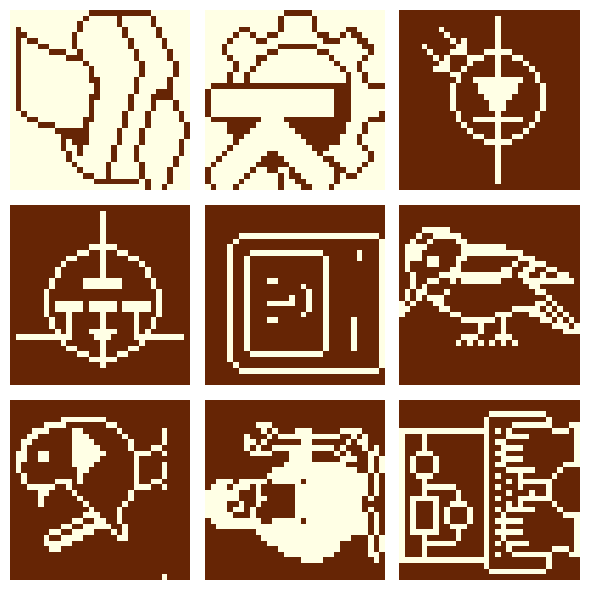

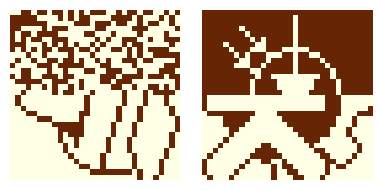

In [2]:
raw_data = np.loadtxt(fname="./data_lab3/pict.dat", delimiter=",", dtype=np.int64)
images = raw_data.copy().reshape(11, 32, 32)

fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Patterns
for i in range(9):
    id_col = i % 3
    id_row = i // 3

    axes[id_row][id_col].imshow(images[i], cmap='YlOrBr')
    axes[id_row][id_col].set_axis_off()

plt.tight_layout()
plt.show()

# Degenerate
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(images[9], cmap='YlOrBr')
axes[0].set_axis_off()

axes[1].imshow(images[10], cmap='YlOrBr')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 3.1. Convergence and attractors

In [3]:
def sign(x):
    return np.where(x >= 0, 1, -1)

def little_recall(W, x, max_iter=100):
    for it in range(max_iter):
        x_new = sign(W @ x)
        if np.array_equal(x_new, x):
            return x, it
        x = x_new
    return x, max_iter

x1 = np.array([-1, -1, 1, -1, 1, -1, -1, 1])
x2 = np.array([-1, -1, -1, -1, -1, 1, -1, -1])
x3 = np.array([-1, 1, 1, -1, -1, 1, -1, 1])
X = np.vstack([x1, x2, x3])

W = X.T @ X

for i, x in enumerate(X):
    print(f"x{i + 1} stable: {np.array_equal(sign(W @ x), x)}")

x1 stable: True
x2 stable: True
x3 stable: True


In [4]:
x1d = np.array([1, -1, 1, -1, 1, -1, -1, 1])
x2d = np.array([1, 1, -1, -1, -1, 1, -1, -1])
x3d = np.array([1, 1, 1, -1, 1, 1, -1, 1])

for i, xd in enumerate([x1d, x2d, x3d]):
    x, it = little_recall(W, xd)
    print(f"x{i + 1}d -> {x} after {it} iterations, equals x{i + 1}: {np.array_equal(x, X[i])}")

x1d -> [-1 -1  1 -1  1 -1 -1  1] after 1 iterations, equals x1: True
x2d -> [-1  1 -1 -1 -1  1 -1 -1] after 1 iterations, equals x2: False
x3d -> [-1  1  1 -1 -1  1 -1  1] after 2 iterations, equals x3: True


In [5]:
states = np.array(list(itertools.product([-1, 1], repeat=8)))
attractors = np.unique([little_recall(W, s)[0] for s in states], axis=0)

print(f"Number of attractors: {len(attractors)}")
for a in attractors:
    print(a)

Number of attractors: 14
[-1 -1 -1 -1 -1  1 -1 -1]
[-1 -1 -1 -1  1 -1 -1 -1]
[-1 -1  1 -1 -1  1 -1  1]
[-1 -1  1 -1  1 -1 -1  1]
[-1 -1  1 -1  1  1 -1  1]
[-1  1 -1 -1 -1  1 -1 -1]
[-1  1  1 -1 -1  1 -1  1]
[-1  1  1 -1  1 -1 -1  1]
[ 1 -1 -1  1  1 -1  1 -1]
[ 1  1 -1  1 -1  1  1 -1]
[ 1  1 -1  1  1 -1  1 -1]
[ 1  1 -1  1  1  1  1 -1]
[ 1  1  1  1 -1  1  1  1]
[ 1  1  1  1  1 -1  1  1]


In [6]:
rng = np.random.default_rng(42)

for n_flips in [3, 4, 5, 6]:
    for i, x in enumerate(X):
        xd = x.copy()
        xd[rng.choice(8, size=n_flips, replace=False)] *= -1
        res, _ = little_recall(W, xd)
        found = [f"x{j + 1}" for j in range(3) if np.array_equal(res, X[j])]
        found += [f"-x{j + 1}" for j in range(3) if np.array_equal(res, -X[j])]
        print(f"{n_flips} flips on x{i + 1} -> {found if found else 'spurious'}")

3 flips on x1 -> spurious
3 flips on x2 -> spurious
3 flips on x3 -> ['-x2']
4 flips on x1 -> ['-x2']
4 flips on x2 -> ['-x3']
4 flips on x3 -> spurious
5 flips on x1 -> ['-x2']
5 flips on x2 -> ['-x2']
5 flips on x3 -> ['-x2']
6 flips on x1 -> ['-x1']
6 flips on x2 -> spurious
6 flips on x3 -> ['-x2']


## 3.2. Sequential Update

In [7]:
patterns = images.reshape(11, 1024)
W = patterns[:3].T @ patterns[:3]

for i in range(3):
    print(f"p{i + 1} stable: {np.array_equal(sign(W @ patterns[i]), patterns[i])}")

p1 stable: True
p2 stable: True
p3 stable: True


p10: converged after 1 iterations
p11: converged after 2 iterations


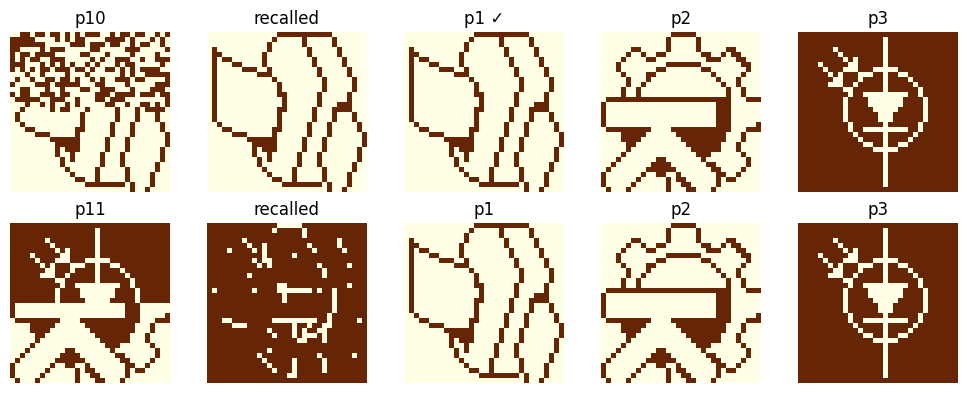

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for row, k in enumerate([9, 10]):
    x, it = little_recall(W, patterns[k])
    print(f"p{k + 1}: converged after {it} iterations")
    axes[row][0].imshow(patterns[k].reshape(32, 32), cmap='YlOrBr')
    axes[row][0].set_title(f"p{k + 1}")
    axes[row][1].imshow(x.reshape(32, 32), cmap='YlOrBr')
    axes[row][1].set_title("recalled")
    for j in range(3):
        axes[row][j + 2].imshow(patterns[j].reshape(32, 32), cmap='YlOrBr')
        axes[row][j + 2].set_title(f"p{j + 1}{' ✓' if np.array_equal(x, patterns[j]) else ''}")

for ax in axes.flat:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [9]:
def sequential_recall(W, x, n_iter, step):
    x = x.copy()
    snapshots = [x.copy()]
    for t in range(1, n_iter + 1):
        i = np.random.randint(len(x))
        x[i] = 1 if W[i] @ x >= 0 else -1
        if t % step == 0:
            snapshots.append(x.copy())
    return snapshots

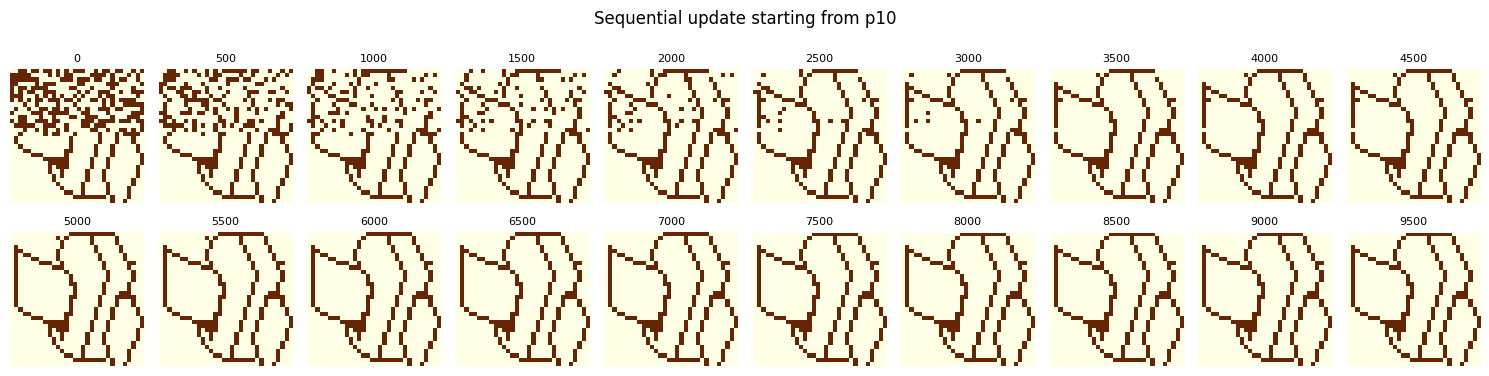

p10: bits different from p1, p2, p3 -> [np.int64(0), np.int64(310), np.int64(768)]


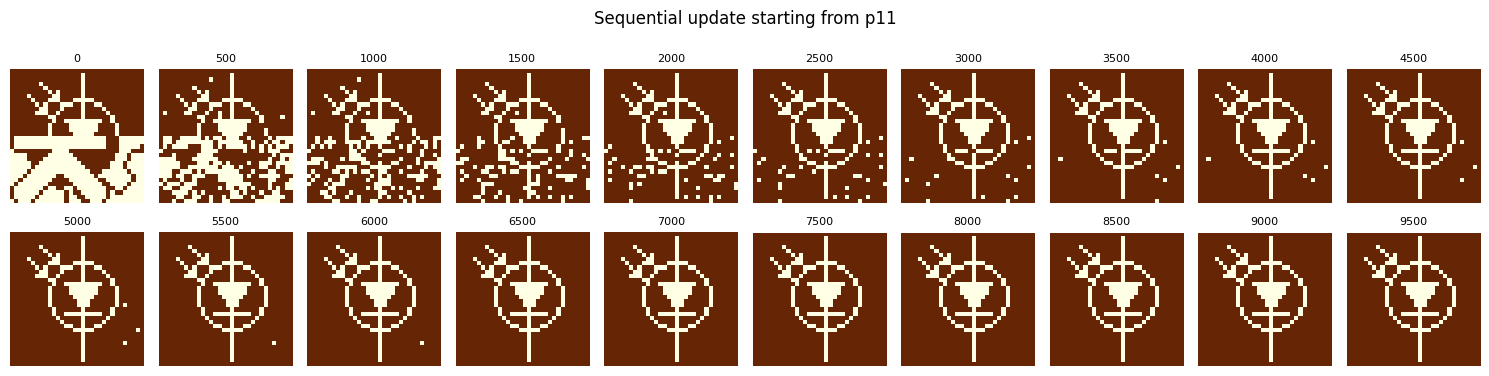

p11: bits different from p1, p2, p3 -> [np.int64(768), np.int64(728), np.int64(0)]


In [10]:
n_iter, step = 9500, 500

for k in [9, 10]:
    snapshots = sequential_recall(W, patterns[k], n_iter, step)
    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    for j, (ax, s) in enumerate(zip(axes.flat, snapshots)):
        ax.imshow(s.reshape(32, 32), cmap='YlOrBr')
        ax.set_title(f"{j * step}", fontsize=8)
        ax.set_axis_off()
    fig.suptitle(f"Sequential update starting from p{k + 1}")
    plt.tight_layout()
    plt.show()
    diffs = [np.sum(snapshots[-1] != patterns[j]) for j in range(3)]
    print(f"p{k + 1}: bits different from p1, p2, p3 -> {diffs}")

## 3.3. Energy

------------------------------------------------------------------------------------------------------------------------
Energy for the 1st pattern: -490288.000
Energy for the 2nd pattern: -465114.667
Energy for the 3rd pattern: -498090.667
------------------------------------------------------------------------------------------------------------------------
Energy for the 1st degenerate pattern: -140964.000
Energy for the 2nd degenerate pattern: -58197.333
------------------------------------------------------------------------------------------------------------------------


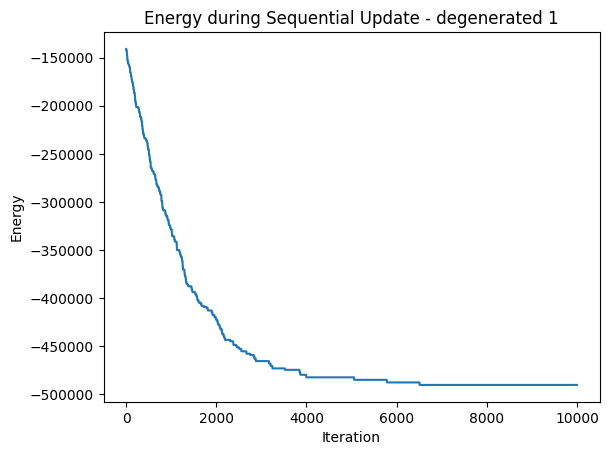

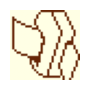

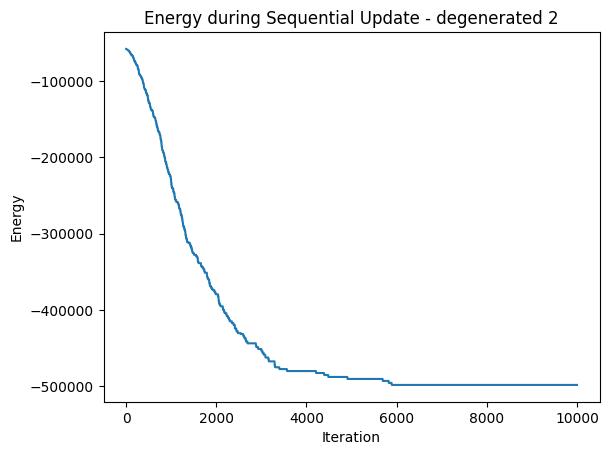

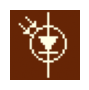

------------------------------------------------------------------------------------------------------------------------


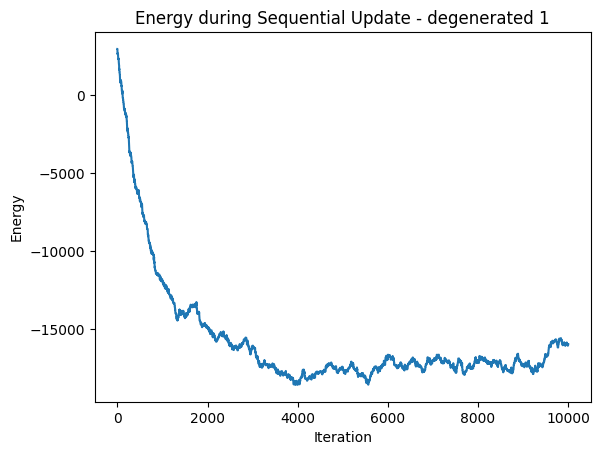

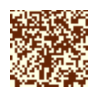

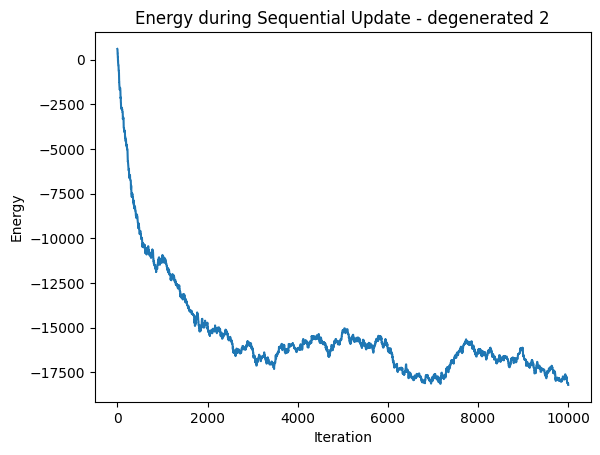

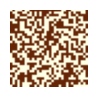

------------------------------------------------------------------------------------------------------------------------


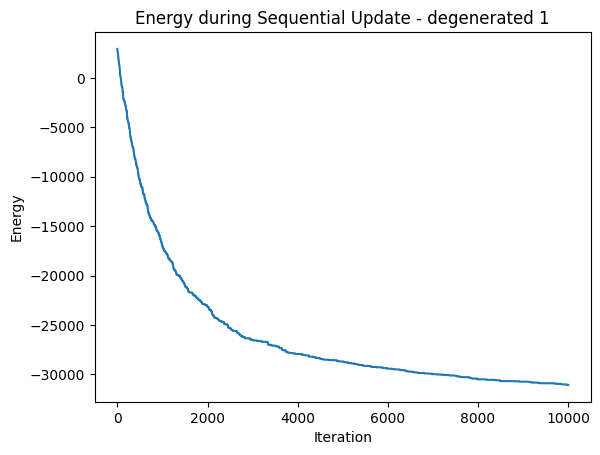

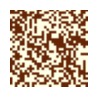

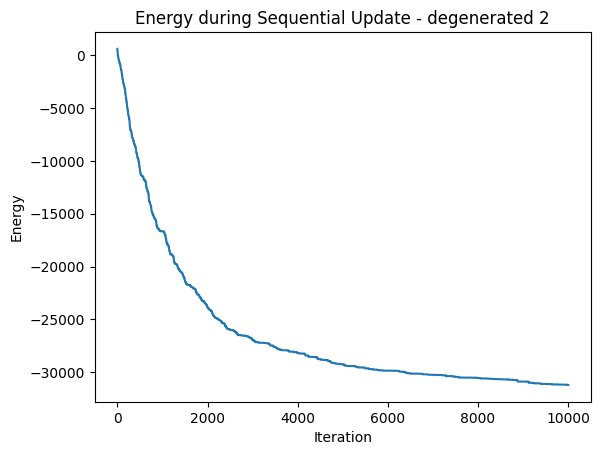

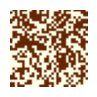

In [11]:
# Train on first P patterns
P = 3
D = 2
dim = 1024
training_set = images[:P,:,:].copy().reshape(P, dim).T
degenerate = images[9:,:,:].copy().reshape(D, dim).T

W = training_set @ training_set.T / P
np.fill_diagonal(W, 0)

# Energy function
def energy(W, x):
    return -float(x.T @ (W @ x))

print("-" * 120)

print(f"Energy for the 1st pattern: {energy(W, training_set[:,0]):.3f}")
print(f"Energy for the 2nd pattern: {energy(W, training_set[:,1]):.3f}")
print(f"Energy for the 3rd pattern: {energy(W, training_set[:,2]):.3f}")

print("-" * 120)

print(f"Energy for the 1st degenerate pattern: {energy(W, degenerate[:,0]):.3f}")
print(f"Energy for the 2nd degenerate pattern: {energy(W, degenerate[:,1]):.3f}") 

print("-" * 120)

for j in range(D):
    x = degenerate[:, j].copy()
    energies = [energy(W, x)]

    for i in range(EPOCHS):
        i = np.random.randint(0, len(x))
        local_field = W[i, :] @ x
        x[i] = 1 if local_field >= 0 else -1
        energies.append(energy(W, x))

    plt.plot(energies)
    plt.title(f"Energy during Sequential Update - degenerated {j + 1}")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.show()

    fig, axes = plt.subplots(1, 1, figsize=(1, 2))

    axes.imshow(x.reshape(32, 32), cmap='YlOrBr')
    axes.set_axis_off()

    plt.tight_layout()
    plt.show()

print("-" * 120)

rand_W = np.random.normal(loc=0, scale=1, size=(dim, dim))
np.fill_diagonal(rand_W, 0)

rec_1 = {"0": None, "1": None}

W_1 = rand_W.copy()

for j in range(D):
    x = degenerate[:, j].copy()
    energies = [energy(W_1, x)]

    for i in range(EPOCHS):
        i = np.random.randint(0, len(x))
        local_field = W_1[i, :] @ x
        x[i] = 1 if local_field >= 0 else -1
        energies.append(energy(W_1, x))

    plt.plot(energies)
    plt.title(f"Energy during Sequential Update - degenerated {j + 1}")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.show()

    fig, axes = plt.subplots(1, 1, figsize=(1, 2))

    axes.imshow(x.reshape(32, 32), cmap='YlOrBr')
    axes.set_axis_off()
    plt.show()

print("-" * 120)

W_2 = rand_W.copy()
W_2 = 0.5 * (W_2 + W_2.T)

for j in range(D):
    x = degenerate[:, j].copy()
    energies = [energy(W_2, x)]

    for epoch in range(EPOCHS):
        i = np.random.randint(0, len(x))
        local_field = W_2[i, :] @ x
        x[i] = 1 if local_field >= 0 else -1
        energies.append(energy(W_2, x))

    plt.plot(energies)
    plt.title(f"Energy during Sequential Update - degenerated {j + 1}")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.show()

    fig, axes = plt.subplots(1, 1, figsize=(1, 2))

    axes.imshow(x.reshape(32, 32), cmap='YlOrBr')
    axes.set_axis_off()
    plt.show()

## 3.4. Distortion Resistance

In [12]:
'''
# Train on the first P patterns
# Train on first P patterns
P = 3
D = 2
dim = 1024
training_set = images[:P,:,:].copy().reshape(P, dim).T
degenerate = images[9:,:,:].copy().reshape(D, dim).T

W = training_set @ training_set.T / P
np.fill_diagonal(W, 0)

percentages = np.arange(0, 101, 1)

at1 = None
at2 = None
at3 = None

at1_50 = None
at2_50 = None
at3_50 = None

attractor_hist = {
    "0": {
        "one": [],
        "many": []
    },
    "1": {
        "one": [],
        "many": []
    },
    "2": {
        "one": [],
        "many": []
    }
}

for i in range(P):
    for p in percentages:
        x = training_set[:, i].copy()
        x[np.random.choice(dim, size=int(p * dim / 100), replace=False)] *= (-1)

        # Little model update
        for j in range(EPOCHS):
            x = (x @ W)
            x[x < 0] = -1
            x[x >= 0] = 1

            if j == 0:
                difference = np.sum(training_set[:, i] != x) / dim
                attractor_hist[f"{i}"]["one"].append(difference)

        if i == 0:
            if p == 90:
              at1 = x.copy()
            if p == 50:
                at1_50 = x.copy()
        elif i == 1:
            if p == 90:
              at2 = x.copy()
            if p == 50:
                at2_50 = x.copy()
        elif i == 2:
            if p == 90:
              at3 = x.copy()
            if p == 50:
                at3_50 = x.copy()

        # Big model update

        difference = np.sum(training_set[:, i] != x) / dim
        attractor_hist[f"{i}"]["many"].append(difference)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for i in range(P):
    axes[i].plot(percentages, attractor_hist[f"{i}"]["one"], label="Single-step recall")
    axes[i].plot(percentages, attractor_hist[f"{i}"]["many"], label=f"{EPOCHS}-step recall")
    axes[i].set_title(f"Attractor {i + 1}")
    axes[i].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(6, 2))

axes[0].imshow(at1.reshape(32, 32), cmap='YlOrBr')
axes[0].set_axis_off()
axes[0].set_title("Attractor 1")

axes[1].imshow(at2.reshape(32, 32), cmap='YlOrBr')
axes[1].set_axis_off()
axes[1].set_title("Attractor 2")

axes[2].imshow(at3.reshape(32, 32), cmap='YlOrBr')
axes[2].set_axis_off()
axes[2].set_title("Attractor 3")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(6, 2))

axes[0].imshow(at1_50.reshape(32, 32), cmap='YlOrBr')
axes[0].set_axis_off()
axes[0].set_title("Attractor 1")

axes[1].imshow(at2_50.reshape(32, 32), cmap='YlOrBr')
axes[1].set_axis_off()
axes[1].set_title("Attractor 2")

axes[2].imshow(at3_50.reshape(32, 32), cmap='YlOrBr')
axes[2].set_axis_off()
axes[2].set_title("Attractor 3")

plt.tight_layout()
plt.show()
'''

'\n# Train on the first P patterns\n# Train on first P patterns\nP = 3\nD = 2\ndim = 1024\ntraining_set = images[:P,:,:].copy().reshape(P, dim).T\ndegenerate = images[9:,:,:].copy().reshape(D, dim).T\n\nW = training_set @ training_set.T / P\nnp.fill_diagonal(W, 0)\n\npercentages = np.arange(0, 101, 1)\n\nat1 = None\nat2 = None\nat3 = None\n\nat1_50 = None\nat2_50 = None\nat3_50 = None\n\nattractor_hist = {\n    "0": {\n        "one": [],\n        "many": []\n    },\n    "1": {\n        "one": [],\n        "many": []\n    },\n    "2": {\n        "one": [],\n        "many": []\n    }\n}\n\nfor i in range(P):\n    for p in percentages:\n        x = training_set[:, i].copy()\n        x[np.random.choice(dim, size=int(p * dim / 100), replace=False)] *= (-1)\n\n        # Little model update\n        for j in range(EPOCHS):\n            x = (x @ W)\n            x[x < 0] = -1\n            x[x >= 0] = 1\n\n            if j == 0:\n                difference = np.sum(training_set[:, i] != x) / dim

## 3.5. Capacity
*Section 3.4 is commented out because it takes very long to run.*

Patterns stored for this iteration:  1
pattern  1  stable:  True


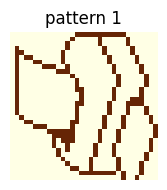

Patterns stored for this iteration:  3
pattern  1  stable:  True
pattern  2  stable:  True
pattern  3  stable:  True


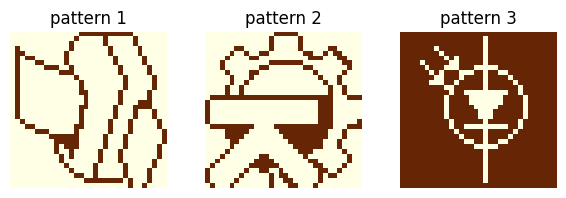

Patterns stored for this iteration:  4
pattern  1  stable:  False
pattern  2  stable:  False
pattern  3  stable:  False
pattern  4  stable:  False


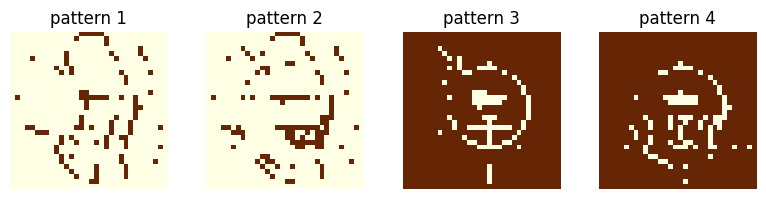

Patterns stored for this iteration:  8
pattern  1  stable:  False
pattern  2  stable:  False
pattern  3  stable:  False
pattern  4  stable:  False
pattern  5  stable:  False
pattern  6  stable:  False
pattern  7  stable:  False
pattern  8  stable:  False


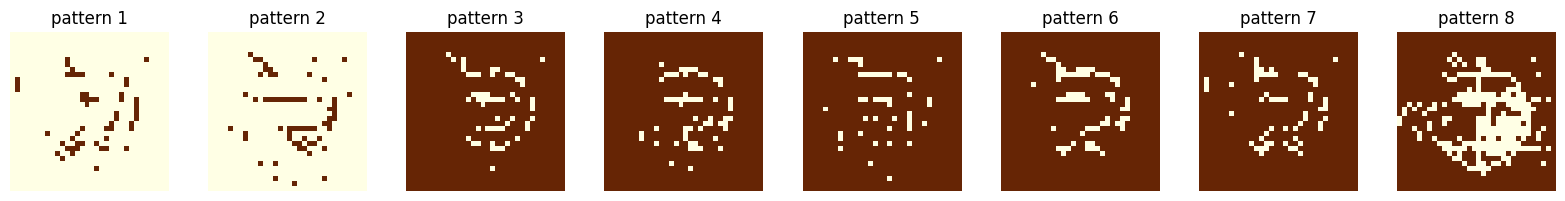

Patterns stored for this iteration:  11
pattern  1  stable:  False
pattern  2  stable:  False
pattern  3  stable:  False
pattern  4  stable:  False
pattern  5  stable:  False
pattern  6  stable:  False
pattern  7  stable:  False
pattern  8  stable:  False
pattern  9  stable:  False
pattern  10  stable:  False
pattern  11  stable:  True


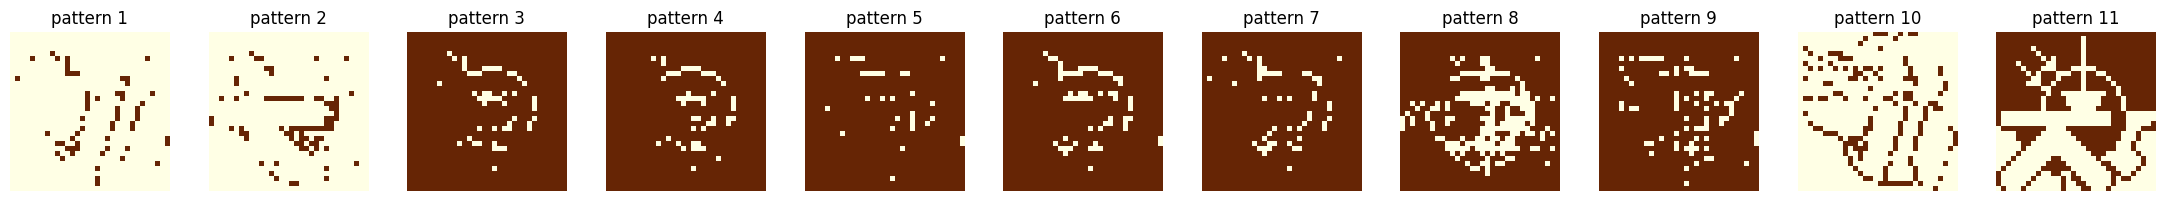

In [13]:
for i in range(len(patterns)):
    W = patterns[:i + 1].T @ patterns[:i + 1]
    iterations = i == 0 or i == 2 or i == 3 or i == 7 or i == 10
    if iterations:
        print("Patterns stored for this iteration: ", (i + 1))
    reconstructed_images = []
    for x in range(i + 1):
        reconstructed = sign(W @ patterns[x])
        stable = np.array_equal(
            reconstructed,
            patterns[x]
        )
        if iterations:
            reconstructed_images.append(reconstructed.reshape(32, 32))
        if iterations:
            print("pattern ", x+1, " stable: ", stable)

    if iterations:
        fix, axes = plt.subplots(
            1, 
            i + 1,
            figsize = (2 * (i + 1), 2)
        )
        if i == 0:
            axes = [axes]
        for x in range(i + 1):
            axes[x].imshow(reconstructed_images[x], cmap="YlOrBr")
            axes[x].set_title(f"pattern {x + 1}")
            axes[x].set_axis_off()
    
        plt.tight_layout()
        plt.show()

In [14]:
num_patterns = 100
image_size = 32



for i in range(num_patterns):
    iterations = i == 49 or i == 74  or i == 79 or i == 99
    counter = 0 
    if iterations:
        print("Patterns stored for this iteration across 10 trials: ", (i + 1))
        for y in range(10):
            patterns = np.random.choice(
                [-1, 1],
                size = (num_patterns, image_size ** 2)
            )
            W = patterns[:i + 1].T @ patterns[:i + 1]
            for x in range(i + 1):
                reconstructed = sign(W @ patterns[x])
                stable = np.array_equal(
                    reconstructed,
                    patterns[x]
                )
                if iterations:
                    if stable:
                        counter += 1
        print(counter / 10, " / ", i + 1)

Patterns stored for this iteration across 10 trials:  50
50.0  /  50
Patterns stored for this iteration across 10 trials:  75
72.9  /  75
Patterns stored for this iteration across 10 trials:  80
75.2  /  80
Patterns stored for this iteration across 10 trials:  100
80.9  /  100


In [15]:
'''
num_patterns = 300
image_size = 32

results = []

for y in range(5):
    print(".")
    patterns = np.random.choice(
            [-1, 1],
            size = (num_patterns, image_size ** 2)
        )
    trial = []
    for i in range(100):
        W = patterns[:(i * 3) + 1].T @ patterns[:(i * 3) + 1]
        np.fill_diagonal(W, 0)
        counter = 0
        for x in range((i * 3) + 1):
            reconstructed = sign(W @ patterns[x])
            stable = np.array_equal(
                reconstructed,
                patterns[x]
            )
            if stable:
                counter += 1
        trial.append(counter)
    results.append(trial)
results = np.array(results)
mean = np.mean(results, axis = 0)
std = np.std(results, axis = 0)

x = np.arange(1, num_patterns, 3)
plt.figure(figsize=(8,5))
plt.plot(x, mean, label = "mean stable patterns")
plt.fill_between(
    x, mean - std, mean + std, alpha = 0.2, label = "standard deviation"
)
plt.xlabel("patterns stored")
plt.ylabel("stable patterns")
plt.legend()
plt.show()
'''

'\nnum_patterns = 300\nimage_size = 32\n\nresults = []\n\nfor y in range(5):\n    print(".")\n    patterns = np.random.choice(\n            [-1, 1],\n            size = (num_patterns, image_size ** 2)\n        )\n    trial = []\n    for i in range(100):\n        W = patterns[:(i * 3) + 1].T @ patterns[:(i * 3) + 1]\n        np.fill_diagonal(W, 0)\n        counter = 0\n        for x in range((i * 3) + 1):\n            reconstructed = sign(W @ patterns[x])\n            stable = np.array_equal(\n                reconstructed,\n                patterns[x]\n            )\n            if stable:\n                counter += 1\n        trial.append(counter)\n    results.append(trial)\nresults = np.array(results)\nmean = np.mean(results, axis = 0)\nstd = np.std(results, axis = 0)\n\nx = np.arange(1, num_patterns, 3)\nplt.figure(figsize=(8,5))\nplt.plot(x, mean, label = "mean stable patterns")\nplt.fill_between(\n    x, mean - std, mean + std, alpha = 0.2, label = "standard deviation"\n)\nplt.xl

In [16]:
'''
num_patterns = 300
image_size = 32
noise = 0.05
results = []

for y in range(5):
    print(".")
    patterns = np.random.choice(
            [-1, 1],
            size = (num_patterns, image_size ** 2)
        )
    
    trial = []
    for i in range(100):
        W = patterns[:(i * 3) + 1].T @ patterns[:(i * 3) + 1]
        np.fill_diagonal(W, 0)
        counter = 0
        for x in range((i * 3) + 1):
            noisy_pattern = patterns[x].copy()
            flip = np.random.rand(len(noisy_pattern)) < noise
            noisy_pattern[flip] *= -1
            reconstructed = sign(W @ noisy_pattern)
            stable = np.array_equal(
                reconstructed,
                patterns[x]
            )
            if stable:
                counter += 1
        trial.append(counter)
    results.append(trial)

results = np.array(results)
mean = np.mean(results, axis = 0)
std = np.std(results, axis = 0)

x = np.arange(1, num_patterns, 3)
plt.figure(figsize=(8,5))
plt.plot(x, mean, label = "mean stable patterns")
plt.fill_between(
    x, mean - std, mean + std, alpha = 0.2, label = "standard deviation"
)
plt.xlabel("patterns stored")
plt.ylabel("stable patterns")
plt.legend()
plt.show()
'''

'\nnum_patterns = 300\nimage_size = 32\nnoise = 0.05\nresults = []\n\nfor y in range(5):\n    print(".")\n    patterns = np.random.choice(\n            [-1, 1],\n            size = (num_patterns, image_size ** 2)\n        )\n\n    trial = []\n    for i in range(100):\n        W = patterns[:(i * 3) + 1].T @ patterns[:(i * 3) + 1]\n        np.fill_diagonal(W, 0)\n        counter = 0\n        for x in range((i * 3) + 1):\n            noisy_pattern = patterns[x].copy()\n            flip = np.random.rand(len(noisy_pattern)) < noise\n            noisy_pattern[flip] *= -1\n            reconstructed = sign(W @ noisy_pattern)\n            stable = np.array_equal(\n                reconstructed,\n                patterns[x]\n            )\n            if stable:\n                counter += 1\n        trial.append(counter)\n    results.append(trial)\n\nresults = np.array(results)\nmean = np.mean(results, axis = 0)\nstd = np.std(results, axis = 0)\n\nx = np.arange(1, num_patterns, 3)\nplt.figure(f

.
.
.
.
.


ValueError: x and y must have same first dimension, but have shapes (48,) and (50,)

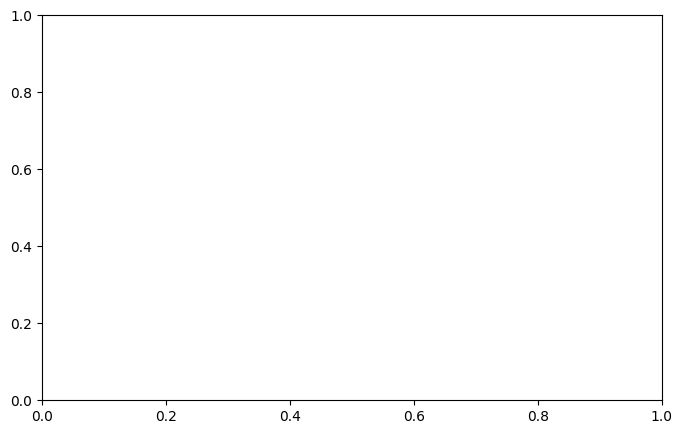

In [17]:

num_patterns = 300
image_size = 32
noise = 0.05
results = []

for y in range(5):
    print(".")

    patterns = np.sign(
            0.5 + np.random.randn(300, 1024)
        )
    
    trial = []
    for i in range(50):
        W = patterns[:(i) + 1].T @ patterns[:(i) + 1]
        np.fill_diagonal(W, 0)
        counter = 0
        for x in range((i) + 1):
            reconstructed = sign(W @ patterns[x])
            stable = np.array_equal(
                reconstructed,
                patterns[x]
            )
            if stable:
                counter += 1
        trial.append(counter)
    results.append(trial)

results = np.array(results)
mean = np.mean(results, axis = 0)
std = np.std(results, axis = 0)

x = np.arange(1, 49)
plt.figure(figsize=(8,5))
plt.plot(x, mean, label = "mean stable patterns")
plt.fill_between(
    x, mean - std, mean + std, alpha = 0.2, label = "standard deviation"
)
plt.xlabel("patterns stored")
plt.ylabel("stable patterns")
plt.legend()
plt.show()


## 3.6. Sparse Patterns

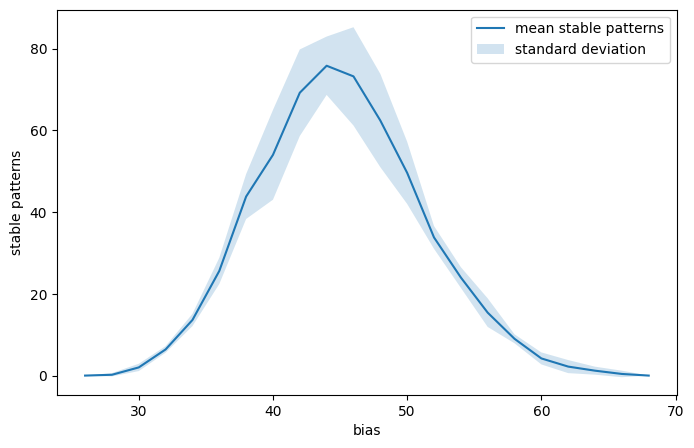

In [48]:
values = np.arange(26, 70, 2)

def sign(x):
    return np.where(x >= 0, 1, -1)

def little_recall(W, x, bias):
    return 0.5 + 0.5 * sign(W @ x - bias)


results = []

for y in range(5):
    patterns = np.where(np.random.rand(300, 1024) < 0.1, 1, 0)
    ratio = np.mean(patterns)

    X_centered = patterns - ratio
    W = X_centered.T @ X_centered
    np.fill_diagonal(W, 0)
    trial = []
    for value in values:
        counter = 0
        for i in range(300):
            reconstructed = little_recall(W, patterns[i], value)
            if np.array_equal(reconstructed, patterns[i]):
                counter += 1
        trial.append(counter)
    results.append(trial)
            
    

results = np.array(results)
mean = np.mean(results, axis = 0)
std = np.std(results, axis = 0)

x = values
plt.figure(figsize=(8,5))
plt.plot(x, mean, label = "mean stable patterns")
plt.fill_between(
    x, mean - std, mean + std, alpha = 0.2, label = "standard deviation"
)
plt.xlabel("bias")
plt.ylabel("stable patterns")
plt.legend()
plt.show()